In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [44]:

df=pd.read_csv("population_by_country_2020.csv")

In [45]:
df.head(10)

,Country (or dependency),Population (2020),Yearly Change,Net Change,Density (P/Km²),Land Area (Km²),Migrants (net),Fert. Rate,Med. Age,Urban Pop %,World Share
0,China,1440297825,0.39 %,5540090,153,9388211,-348399.0,1.7,38,61 %,18.47 %
1,India,1382345085,0.99 %,13586631,464,2973190,-532687.0,2.2,28,35 %,17.70 %
2,United States,331341050,0.59 %,1937734,36,9147420,954806.0,1.8,38,83 %,4.25 %
3,Indonesia,274021604,1.07 %,2898047,151,1811570,-98955.0,2.3,30,56 %,3.51 %
4,Pakistan,221612785,2.00 %,4327022,287,770880,-233379.0,3.6,23,35 %,2.83 %
5,Brazil,212821986,0.72 %,1509890,25,8358140,21200.0,1.7,33,88 %,2.73 %
6,Nigeria,206984347,2.58 %,5175990,226,910770,-60000.0,5.4,18,52 %,2.64 %
7,Bangladesh,164972348,1.01 %,1643222,1265,130170,-369501.0,2.1,28,39 %,2.11 %
8,Russia,145945524,0.04 %,62206,9,16376870,182456.0,1.8,40,74 %,1.87 %
9,Mexico,129166028,1.06 %,1357224,66,1943950,-60000.0,2.1,29,84 %,1.65 %


In [47]:
percentage_cols = ['Yearly Change', 'Urban Pop %', 'World Share']

for col in percentage_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('%', '', regex=False)
        .str.strip()
        .replace('N.A.', np.nan)
    )

    df[col] = pd.to_numeric(df[col], errors='coerce')

In [48]:
print(df[percentage_cols].dtypes)

Yearly Change    float64
Urban Pop %      float64
World Share      float64
dtype: object


In [49]:
df[percentage_cols].head()

,Yearly Change,Urban Pop %,World Share
0,0.39,61.0,18.47
1,0.99,35.0,17.70
2,0.59,83.0,4.25
3,1.07,56.0,3.51
4,2.00,35.0,2.83


In [50]:
print(df[percentage_cols].isnull().sum())

Yearly Change     0
Urban Pop %      13
World Share       0
dtype: int64


In [51]:
df['Urban Pop %'] = df['Urban Pop %'].fillna(df['Urban Pop %'].median())

In [52]:
print(df[percentage_cols].isnull().sum())

Yearly Change    0
Urban Pop %      0
World Share      0
dtype: int64


In [53]:
print(df[['Med. Age', 'Migrants (net)']].isnull().sum())

Med. Age           0
Migrants (net)    34
dtype: int64


In [54]:
print(df['Med. Age'].dtype)

object


In [55]:
import numpy as np

df['Med. Age'] = (
    df['Med. Age']
    .astype(str)
    .str.strip()
    .replace('N.A.', np.nan)
)

df['Med. Age'] = pd.to_numeric(df['Med. Age'], errors='coerce')

In [56]:
df['Med. Age'] = df['Med. Age'].fillna(df['Med. Age'].median())

In [57]:
df['Migrants (net)'] = (
    df['Migrants (net)']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace('N.A.', np.nan)
)

df['Migrants (net)'] = pd.to_numeric(df['Migrants (net)'], errors='coerce')
df['Migrants (net)'] = df['Migrants (net)'].fillna(0)

In [58]:
print(df[['Med. Age', 'Migrants (net)']].dtypes)

print(df[['Med. Age', 'Migrants (net)']].isnull().sum())

Med. Age          float64
Migrants (net)    float64
dtype: object
Med. Age          0
Migrants (net)    0
dtype: int64


In [59]:
import numpy as np

# Convert Population column to NumPy array
population = df['Population (2020)'].to_numpy()

# Statistics
mean_population = np.mean(population)
median_population = np.median(population)
std_population = np.std(population)
total_population = np.sum(population)

print("Mean Population:", mean_population)
print("Median Population:", median_population)
print("Standard Deviation:", std_population)
print("Total World Population:", total_population)

Mean Population: 33227444.280851062
Median Population: 5460109.0
Standard Deviation: 135015251.93245462
Total World Population: 7808449406


In [60]:
density = df['Density (P/Km²)'].to_numpy()

percentiles = np.percentile(density, [25, 50, 75])

print("25th Percentile:", percentiles[0])
print("50th Percentile (Median):", percentiles[1])
print("75th Percentile:", percentiles[2])

25th Percentile: 37.0
50th Percentile (Median): 95.0
75th Percentile: 239.5


In [61]:
density_label = np.where(
    density > 500,
    "High Density",
    "Low Density"
)

# Add to DataFrame
df["Density Label"] = density_label

print(df[['Country (or dependency)', 'Density (P/Km²)', 'Density Label']].head(10))

  Country (or dependency)  Density (P/Km²) Density Label
0                   China              153   Low Density
1                   India              464   Low Density
2           United States               36   Low Density
3               Indonesia              151   Low Density
4                Pakistan              287   Low Density
5                  Brazil               25   Low Density
6                 Nigeria              226   Low Density
7              Bangladesh             1265  High Density
8                  Russia                9   Low Density
9                  Mexico               66   Low Density


In [62]:
log_population = np.log(population)

print(log_population[:10])

[21.08811575 21.04704723 19.61865877 19.42871751 19.21644221 19.17596663
 19.14815373 18.92128843 18.79874399 18.67660917]


In [63]:
print(df[['Fert. Rate', 'Med. Age']].dtypes)

Fert. Rate     object
Med. Age      float64
dtype: object


In [64]:
df['Med. Age'] = (
    df['Med. Age']
    .astype(str)
    .str.strip()
    .replace('N.A.', np.nan)
)

df['Med. Age'] = pd.to_numeric(
    df['Med. Age'],
    errors='coerce'
)


In [65]:
df['Fert. Rate'] = (
    df['Fert. Rate']
    .astype(str)
    .str.strip()
    .replace('N.A.', np.nan)
)

df['Fert. Rate'] = pd.to_numeric(
    df['Fert. Rate'],
    errors='coerce'
)

In [66]:
df['Migrants (net)'] = (
    df['Migrants (net)']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace('N.A.', np.nan)
)

df['Migrants (net)'] = pd.to_numeric(
    df['Migrants (net)'],
    errors='coerce'
)


In [67]:
df['Urban Pop %'] = df['Urban Pop %'].fillna(
    df['Urban Pop %'].median()
)

df['Med. Age'] = df['Med. Age'].fillna(
    df['Med. Age'].median()
)

df['Migrants (net)'] = df['Migrants (net)'].fillna(0)

df['Fert. Rate'] = df['Fert. Rate'].fillna(
    df['Fert. Rate'].median()
)


print("Cleaning Completed")

Cleaning Completed


In [68]:
print(df[['Med. Age', 'Migrants (net)']].isnull().sum())

Med. Age          0
Migrants (net)    0
dtype: int64


In [69]:

df[['Fert. Rate',
    'Med. Age',
    'Urban Pop %',
    'World Share',
    'Migrants (net)']].dtypes

Fert. Rate        float64
Med. Age          float64
Urban Pop %       float64
World Share       float64
Migrants (net)    float64
dtype: object

In [70]:
fertility = df['Fert. Rate'].to_numpy()
median_age = df['Med. Age'].to_numpy()

corr = np.corrcoef(
    fertility,
    median_age
)

print("Correlation Matrix:")
print(corr)

print("Correlation Coefficient:", corr[0,1])

Correlation Matrix:
[[ 1.         -0.87285931]
 [-0.87285931  1.        ]]
Correlation Coefficient: -0.8728593086956676


In [71]:
df.head(20)

,Country (or dependency),Population (2020),Yearly Change,Net Change,Density (P/Km²),Land Area (Km²),Migrants (net),Fert. Rate,Med. Age,Urban Pop %,World Share,Density Label
0,China,1440297825,0.39,5540090,153,9388211,-348399.0,1.7,38.0,61.0,18.47,Low Density
1,India,1382345085,0.99,13586631,464,2973190,-532687.0,2.2,28.0,35.0,17.70,Low Density
2,United States,331341050,0.59,1937734,36,9147420,954806.0,1.8,38.0,83.0,4.25,Low Density
3,Indonesia,274021604,1.07,2898047,151,1811570,-98955.0,2.3,30.0,56.0,3.51,Low Density
4,Pakistan,221612785,2.00,4327022,287,770880,-233379.0,3.6,23.0,35.0,2.83,Low Density
5,Brazil,212821986,0.72,1509890,25,8358140,21200.0,1.7,33.0,88.0,2.73,Low Density
6,Nigeria,206984347,2.58,5175990,226,910770,-60000.0,5.4,18.0,52.0,2.64,Low Density
7,Bangladesh,164972348,1.01,1643222,1265,130170,-369501.0,2.1,28.0,39.0,2.11,High Density
8,Russia,145945524,0.04,62206,9,16376870,182456.0,1.8,40.0,74.0,1.87,Low Density
9,Mexico,129166028,1.06,1357224,66,1943950,-60000.0,2.1,29.0,84.0,1.65,Low Density


In [72]:
top10_populous = df.sort_values(
    by='Population (2020)', 
    ascending=False
).head(10)
print(top10_populous[['Country (or dependency)','Population (2020)']])

  Country (or dependency)  Population (2020)
0                   China         1440297825
1                   India         1382345085
2           United States          331341050
3               Indonesia          274021604
4                Pakistan          221612785
5                  Brazil          212821986
6                 Nigeria          206984347
7              Bangladesh          164972348
8                  Russia          145945524
9                  Mexico          129166028


In [73]:
print(df['Population (2020)'].dtype)

int64


In [74]:
print(df.columns)

Index(['Country (or dependency)', 'Population (2020)', 'Yearly Change',
       'Net Change', 'Density (P/Km²)', 'Land Area (Km²)', 'Migrants (net)',
       'Fert. Rate', 'Med. Age', 'Urban Pop %', 'World Share',
       'Density Label'],
      dtype='object')


In [75]:
least10_populous = df.sort_values(
    by='Population (2020)',
    ascending=True
).head(10)

print(least10_populous[['Country (or dependency)','Population (2020)']])

     Country (or dependency)  Population (2020)
234                 Holy See                801
233                  Tokelau               1360
232                     Niue               1628
231         Falkland Islands               3497
230               Montserrat               4993
229  Saint Pierre & Miquelon               5789
228             Saint Helena               6080
227         Saint Barthelemy               9882
226                    Nauru              10836
225          Wallis & Futuna              11203


In [76]:
# Sort countries by World Share (highest to lowest)
df_share = df.sort_values(
    by='World Share',
    ascending=False
)

# Calculate cumulative population share
df_share['Cumulative World Share'] = df_share['World Share'].cumsum()

# Find countries contributing to first 50% of world population
top_50 = df_share[
    df_share['Cumulative World Share'] <= 50
]

print(top_50[['Country (or dependency)',
              'World Share',
              'Cumulative World Share']])

print("Number of countries accounting for 50% of world population:",
      len(top_50))

  Country (or dependency)  World Share  Cumulative World Share
0                   China        18.47                   18.47
1                   India        17.70                   36.17
2           United States         4.25                   40.42
3               Indonesia         3.51                   43.93
4                Pakistan         2.83                   46.76
5                  Brazil         2.73                   49.49
Number of countries accounting for 50% of world population: 6


In [77]:
negative_migrants = df[df['Migrants (net)'] < 0]
positive_migrants=df[df['Migrants (net)']>0]
print("Countries with Negative:",len(negative_migrants))
print("Countries with positive :",len(positive_migrants))

Countries with Negative: 113
Countries with positive : 83


In [78]:
# Select only numeric columns
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()
print(corr_matrix)

                   Population (2020)  Yearly Change  Net Change  \
Population (2020)           1.000000      -0.009504    0.852329   
Yearly Change              -0.009504       1.000000    0.190087   
Net Change                  0.852329       0.190087    1.000000   
Density (P/Km²)            -0.025433      -0.026965   -0.033803   
Land Area (Km²)             0.455486       0.009098    0.305668   
Migrants (net)             -0.265861      -0.015156   -0.299763   
Fert. Rate                 -0.036400       0.792957    0.178572   
Med. Age                    0.021360      -0.784583   -0.187200   
Urban Pop %                -0.035369      -0.265367   -0.144123   
World Share                 0.999998      -0.009736    0.851809   

                   Density (P/Km²)  Land Area (Km²)  Migrants (net)  \
Population (2020)        -0.025433         0.455486       -0.265861   
Yearly Change            -0.026965         0.009098       -0.015156   
Net Change               -0.033803         0.3056

In [79]:
# Create categories based on population density

bins = [0, 50, 300, 1000, float('inf')]

labels = [
    'Low',
    'Medium',
    'High',
    'Very High'
]


df['Population Density Category'] = pd.cut(
    df['Density (P/Km²)'],
    bins=bins,
    labels=labels
)


print(df[['Country (or dependency)',
          'Density (P/Km²)',
          'Population Density Category']])

    Country (or dependency)  Density (P/Km²) Population Density Category
0                     China              153                      Medium
1                     India              464                        High
2             United States               36                         Low
3                 Indonesia              151                      Medium
4                  Pakistan              287                      Medium
..                      ...              ...                         ...
230              Montserrat               50                         Low
231        Falkland Islands                0                         NaN
232                    Niue                6                         Low
233                 Tokelau              136                      Medium
234                Holy See             2003                   Very High

[235 rows x 3 columns]


In [81]:
heights_fert_rate = df.sort_values(
    by='Fert. Rate',
    ascending=False
).head(1)
print(heights_fert_rate[['Country (or dependency)','Fert. Rate']])

heights_Mid_rate = df.sort_values(
    by='Med. Age',
    ascending=False
).head(1)
print(heights_Mid_rate[['Country (or dependency)','Med. Age']])

   Country (or dependency)  Fert. Rate
55                   Niger         7.0
   Country (or dependency)  Med. Age
10                   Japan      48.0


In [82]:
result=df[df['Urban Pop %']>90]
result=result.sort_values(
    by='Population (2020)',
    ascending=True
)
print(result[
    ['Country (or dependency)',
     'Urban Pop %',
     'Population (2020)']
])


     Country (or dependency)  Urban Pop %  Population (2020)
229  Saint Pierre & Miquelon        100.0               5789
217               San Marino         97.0              33944
212             Sint Maarten         96.0              42960
205                  Bermuda         97.0              62237
204           Cayman Islands         97.0              65854
198      U.S. Virgin Islands         96.0             104398
190                     Guam         95.0             169031
179                  Iceland         94.0             341628
178               Martinique         92.0             375213
173                    Malta         93.0             441750
161                  Réunion        100.0             896422
138                    Qatar         96.0            2889284
133                  Uruguay         96.0            3475842
99                    Israel         93.0            8678517
87                    Jordan         91.0           10220604
80                   Bel

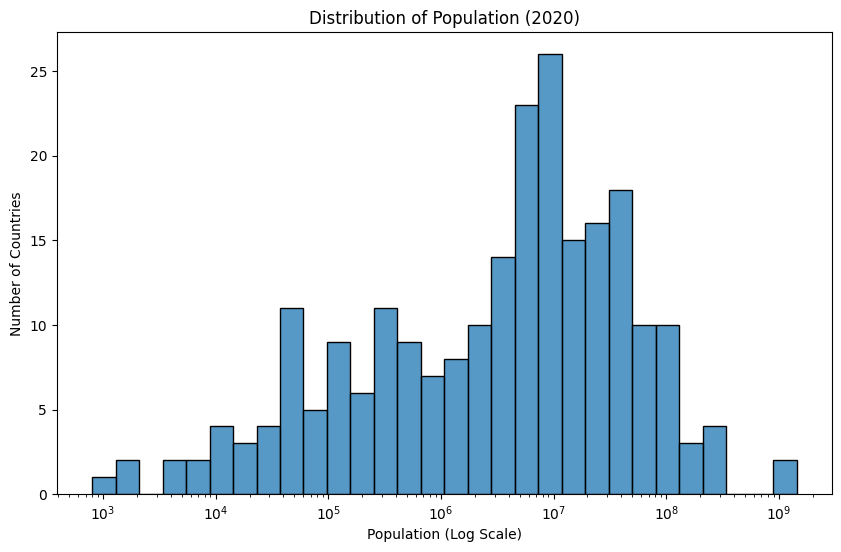

In [83]:
#Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.histplot(
    df['Population (2020)'],
    bins=30,
    log_scale=True
)

plt.title("Distribution of Population (2020)")
plt.xlabel("Population (Log Scale)")
plt.ylabel("Number of Countries")

plt.show()

In [84]:
df['Urban Category'] = df['Urban Pop %'].apply(
    lambda x: 'Above 50%' if x > 50 else 'Below 50%'
)

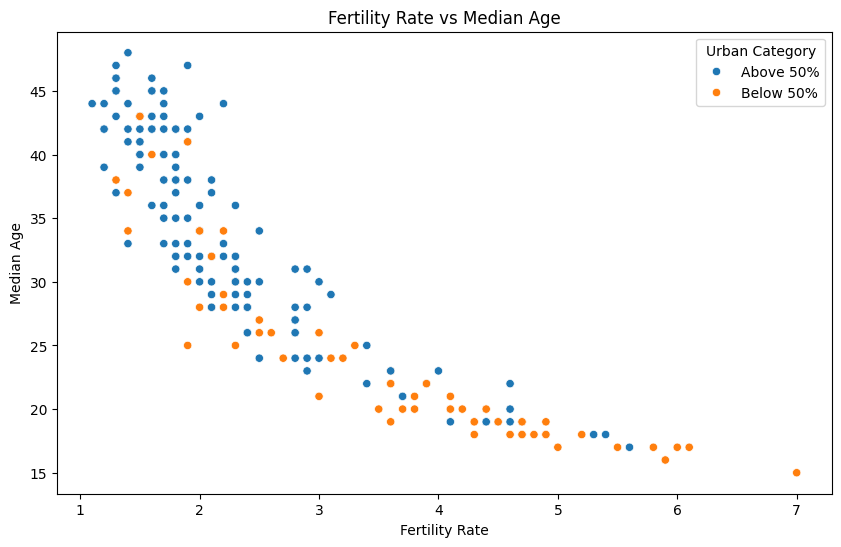

In [85]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Fert. Rate',
    y='Med. Age',
    hue='Urban Category'
)

plt.title("Fertility Rate vs Median Age")
plt.xlabel("Fertility Rate")
plt.ylabel("Median Age")

plt.show()

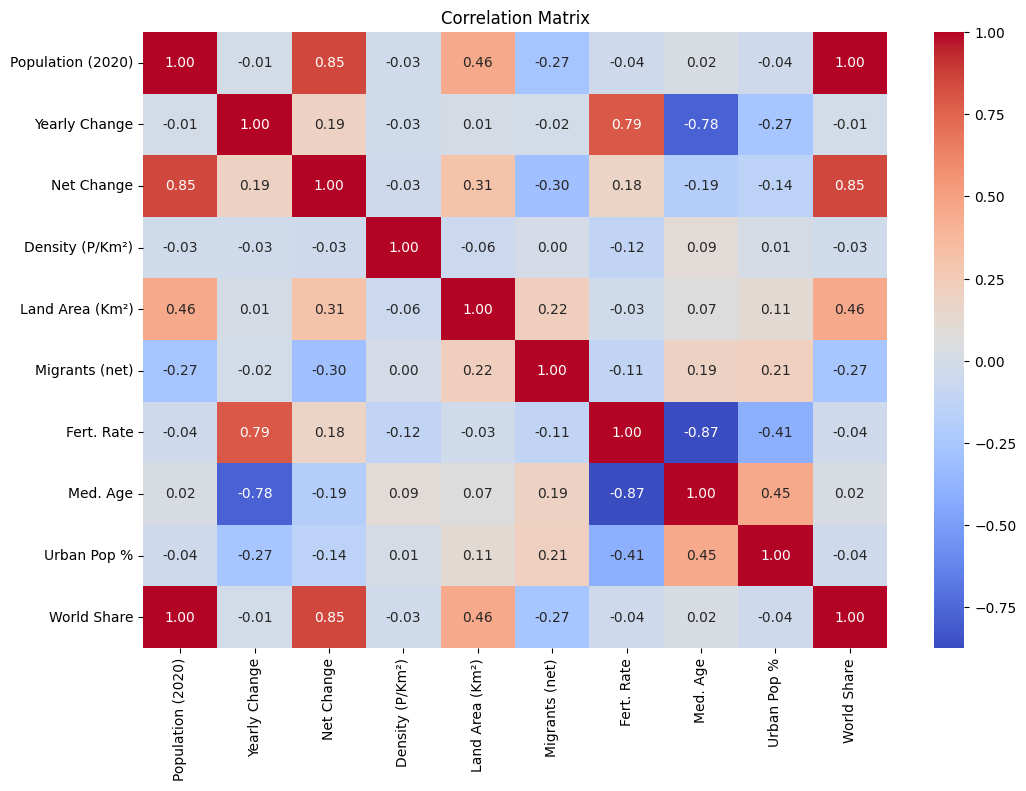

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

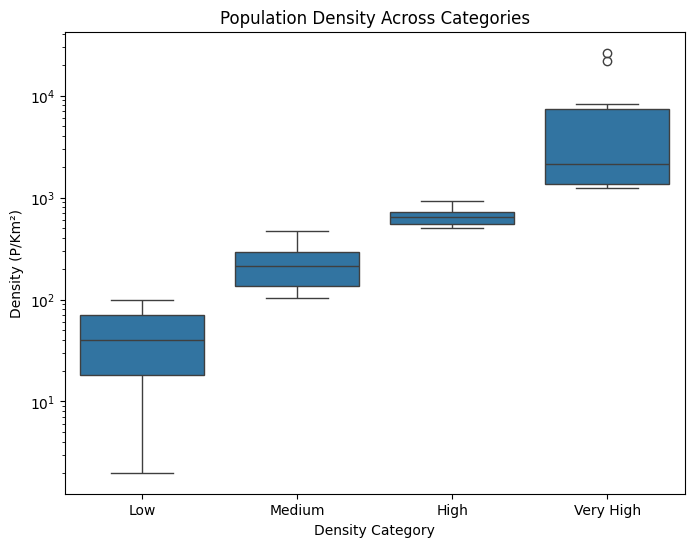

In [87]:

df["Density Category"] = pd.cut(
    df["Density (P/Km²)"],
    bins=[0,100,500,1000,float("inf")],
    labels=["Low","Medium","High","Very High"]
)
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Density Category",
    y="Density (P/Km²)",
    data=df
)

plt.yscale("log")
plt.title("Population Density Across Categories")
plt.show()

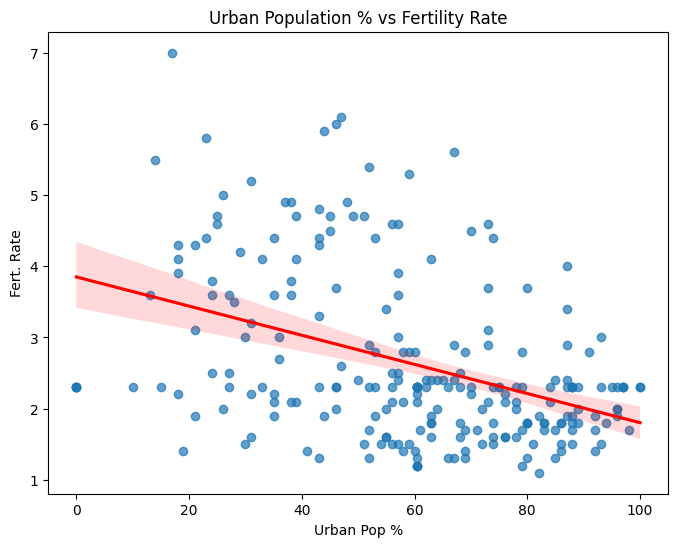

In [88]:
plt.figure(figsize=(8,6))

sns.regplot(
    x="Urban Pop %",
    y="Fert. Rate",
    data=df,
    scatter_kws={"alpha":0.7},
    line_kws={"color":"red"}
)

plt.title("Urban Population % vs Fertility Rate")
plt.show()

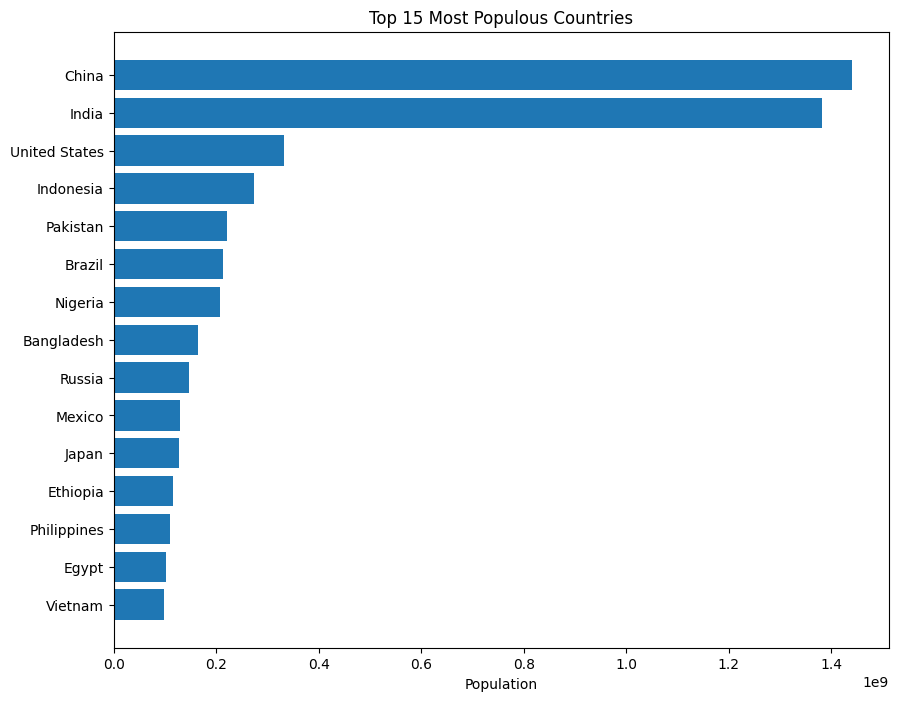

In [89]:
top15 = df.nlargest(15, "Population (2020)")

plt.figure(figsize=(10,8))

plt.barh(
    top15["Country (or dependency)"],
    top15["Population (2020)"]
)

plt.gca().invert_yaxis()

plt.xlabel("Population")
plt.title("Top 15 Most Populous Countries")
plt.show()

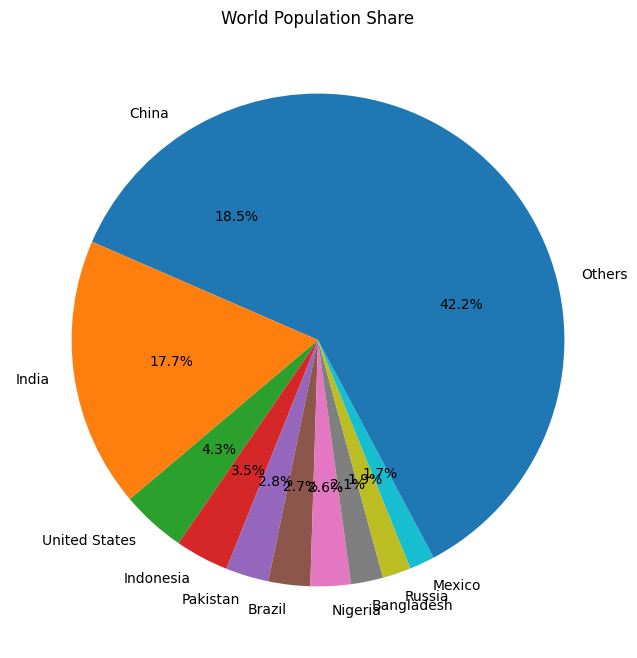

<Figure size 640x480 with 0 Axes>

In [93]:
top10 = df.nlargest(10, "Population (2020)")

others = df["World Share"].sum() - top10["World Share"].sum()

labels = list(top10["Country (or dependency)"])
labels.append("Others")

sizes = list(top10["World Share"])
sizes.append(others)

plt.figure(figsize=(8,8))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("World Population Share")
plt.show()
plt.tight_layout()

In [91]:
print(df.columns.tolist())

['Country (or dependency)', 'Population (2020)', 'Yearly Change', 'Net Change', 'Density (P/Km²)', 'Land Area (Km²)', 'Migrants (net)', 'Fert. Rate', 'Med. Age', 'Urban Pop %', 'World Share', 'Density Label', 'Population Density Category', 'Urban Category', 'Density Category']


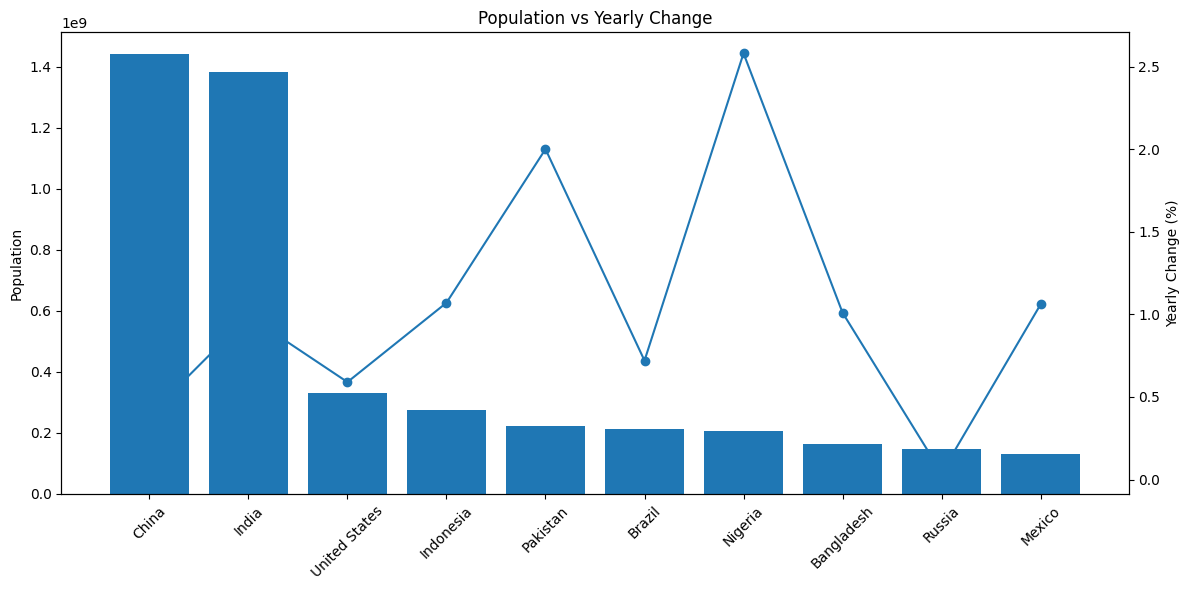

In [94]:
top10 = df.nlargest(10, "Population (2020)")

fig, ax1 = plt.subplots(figsize=(12,6))

# Population Bar
ax1.bar(
    top10["Country (or dependency)"],
    top10["Population (2020)"]
)

ax1.set_ylabel("Population")
ax1.tick_params(axis="x", rotation=45)

# Second Axis
ax2 = ax1.twinx()

ax2.plot(
    top10["Country (or dependency)"],
    top10["Yearly Change"],
    marker="o"
)

ax2.set_ylabel("Yearly Change (%)")

plt.title("Population vs Yearly Change")
plt.tight_layout()
plt.show()

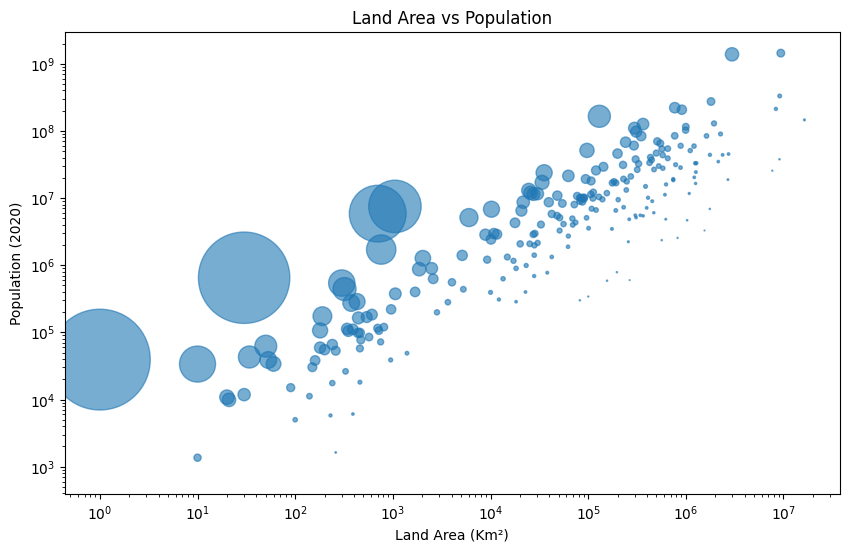

In [95]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Land Area (Km²)"],
    df["Population (2020)"],
    s=df["Density (P/Km²)"]/5,
    alpha=0.6
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Land Area (Km²)")
plt.ylabel("Population (2020)")

plt.title("Land Area vs Population")

plt.show()